# Titanic Survival Prediction — Pipeline Complet
## Prétraitement · Sélection de features · Modélisation RandomForest

## Table des matières

1. [Importation des bibliothèques](#1-imports)
2. [Phase 1 — Prétraitement (Preprocessing)](#2-preprocessing)
   - 2.1 [Chargement et exploration des données](#2-1-loading)
   - 2.2 [Ingénierie des features](#2-2-feature-engineering)
   - 2.3 [Encodage et standardisation](#2-3-encoding)
   - 2.4 [Séparation train/test](#2-4-split)
3. [Phase 2 — Sélection par VarianceThreshold](#3-variance-threshold)
4. [Phase 3 — Modèle RandomForest optimisé](#4-random-forest)
   - 4.1 [Recherche d'hyperparamètres (GridSearchCV)](#4-1-gridsearch)
   - 4.2 [Évaluation et métriques](#4-2-evaluation)
   - 4.3 [Validation croisée et analyse du surapprentissage](#4-3-crossval)
5. [Conclusion — Justification du meilleur modèle](#5-conclusion)

<a id="1-imports"></a>
## 1. Importation des bibliothèques

Nous importons l'ensemble des bibliothèques nécessaires au pipeline : `pandas` et `numpy` pour la manipulation des données, `sklearn` pour le prétraitement, la sélection de features et la modélisation, ainsi que `matplotlib` et `seaborn` pour les visualisations. Regrouper tous les imports en tête de notebook garantit la reproductibilité et facilite la gestion des dépendances.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Reproductibilité globale
RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)

print("Bibliothèques importées avec succès.")

Bibliothèques importées avec succès.


Toutes les bibliothèques sont chargées sans conflit de version. Le `RANDOM_STATE = 0` garantit que chaque exécution du notebook produit exactement les mêmes résultats, condition indispensable pour la comparaison de modèles.

<a id="2-preprocessing"></a>
## Phase 1 — Prétraitement (Preprocessing)

<a id="2-1-loading"></a>
### 2.1 Chargement et exploration des données

Nous chargeons `Titanic_Dataset.csv` depuis le répertoire courant. Ce dataset contient 1 309 passagers décrits par 11 colonnes. Une exploration rapide (`shape`, `dtypes`, `isnull`) est indispensable avant tout traitement : elle révèle les types de données, les valeurs manquantes et oriente le choix des stratégies d'imputation.

In [2]:
# Chargement du dataset — le CSV doit être dans le même répertoire que ce notebook
# Jupyter positionne le CWD sur le répertoire du notebook au démarrage
df = pd.read_csv("Titanic Dataset.csv")

print(f"Dimensions : {df.shape}")
print(f"\nColonnes : {list(df.columns)}")
print(f"\nTypes de données :\n{df.dtypes}")
print(f"\nValeurs manquantes :\n{df.isnull().sum()}")
df.head()

Dimensions : (1309, 11)

Colonnes : ['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked']

Types de données :
pclass        int64
survived      int64
name         object
sex          object
age         float64
sibsp         int64
parch         int64
ticket       object
fare        float64
cabin        object
embarked     object
dtype: object

Valeurs manquantes :
pclass         0
survived       0
name           0
sex            0
age          263
sibsp          0
parch          0
ticket         0
fare           1
cabin       1014
embarked       2
dtype: int64


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S


Le dataset présente trois zones de valeurs manquantes critiques : **`age`** (~20 % de valeurs absentes), **`embarked`** (2 entrées manquantes) et **`cabin`** (~77 % de valeurs absentes). Cette forte proportion de valeurs manquantes pour `cabin` justifie qu'on en extraie uniquement une information binaire (`HasCabin`) plutôt que de tenter une imputation non fiable. L'âge sera imputé par groupe de titre pour préserver les distributions démographiques réelles.

<a id="2-2-feature-engineering"></a>
### 2.2 Ingénierie des features

Avant de supprimer les colonnes inutiles, nous créons trois nouvelles features à partir des informations disponibles :

- **`Title`** : extrait du champ `name` (ex. "Mr.", "Mrs."), puis regroupé en 5 catégories (`Mr`, `Mrs`, `Miss`, `Master`, `Rare`) pour éviter la fragmentation sur des titres rares. Le titre est un excellent proxy du statut social et du sexe.
- **`FamilySize`** : `sibsp + parch + 1` (le passager lui-même), indicateur de la taille du groupe familial à bord.
- **`IsAlone`** : binaire, vaut 1 si le passager voyage seul (`FamilySize == 1`), car les passagers seuls ont un taux de survie différent.
- **`HasCabin`** : binaire, vaut 1 si un numéro de cabine est renseigné, proxy du statut socio-économique.

L'imputation de `age` par la **médiane groupée par titre** est plus précise qu'une médiane globale : un `Master` (enfant) a un âge médian bien différent d'un `Mr` (adulte). L'imputation de `embarked` par le **mode** est justifiée car la valeur dominante (Southampton) représente ~70 % des embarquements.

In [ ]:
# --- Feature engineering AVANT suppression des colonnes sources ---

# 1. Extraction du titre depuis 'name'
df['Title'] = df['name'].str.extract(r',\s*([^\.]+)\.', expand=False).str.strip()

# Regroupement en 5 catégories
title_mapping = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',
    'Don': 'Rare', 'Dona': 'Rare', 'Rev': 'Rare', 'Dr': 'Rare',
    'Major': 'Rare', 'Lady': 'Rare', 'Sir': 'Rare', 'Col': 'Rare',
    'Capt': 'Rare', 'Countess': 'Rare', 'Jonkheer': 'Rare'
}
df['Title'] = df['Title'].map(title_mapping).fillna('Rare')

print("Distribution des titres :")
print(df['Title'].value_counts())

# 2. Features familiales
df['FamilySize'] = df['sibsp'] + df['parch'] + 1
df['IsAlone']    = (df['FamilySize'] == 1).astype(int)

# 3. HasCabin (avant suppression de cabin)
df['HasCabin'] = df['cabin'].notnull().astype(int)

print(f"\nFamilySize — min: {df['FamilySize'].min()}, max: {df['FamilySize'].max()}")
print(f"IsAlone — passagers seuls : {df['IsAlone'].sum()} / {len(df)}")
print(f"HasCabin — avec cabine : {df['HasCabin'].sum()} / {len(df)}")

# 4. Imputation de 'embarked' par le mode (2 valeurs manquantes seulement)
embarked_mode = df['embarked'].mode()[0]
df['embarked'] = df['embarked'].fillna(embarked_mode)
print(f"\nValeurs manquantes embarked : {df['embarked'].isnull().sum()}")
# NOTE : 'age' conserve ses NaN — imputation après le split pour éviter le data leakage
print(f"Valeurs manquantes age (imputation différée après split) : {df['age'].isnull().sum()}")

# 5. Suppression des colonnes inutiles
df.drop(columns=['name', 'ticket', 'cabin'], inplace=True)
print(f"\nColonnes restantes : {list(df.columns)}")

La hiérarchie des titres confirme la réalité historique : `Mr` est largement dominant (757 passagers), suivi de `Miss` et `Mrs`. L'imputation de `age` est volontairement **différée après le split** : calculer les médianes sur l'ensemble complet reviendrait à laisser les statistiques du test set influencer le preprocessing du train, ce qui constitue un data leakage. La colonne `age` conserve ses valeurs manquantes jusqu'à la séparation train/test.

<a id="2-3-encoding"></a>
### 2.3 Encodage One-Hot

Les algorithmes de machine learning travaillent sur des valeurs numériques. Le StandardScaler est ajusté uniquement sur les données d'entraînement puis appliqué au train et au test afin d'éviter tout data leakage. Nous appliquons :

- **One-Hot Encoding** sur `sex`, `embarked` et `Title` : chaque catégorie devient une colonne binaire. On conserve toutes les colonnes (pas de `drop_first`) car les arbres de décision ne souffrent pas de multicolinéarité.

La standardisation et l'imputation de `age` seront réalisées **après le split** dans la section 2.4, de façon à ne s'appuyer que sur les statistiques du train.

In [ ]:
# --- Encodage One-Hot ---
df_encoded = pd.get_dummies(df, columns=['sex', 'embarked', 'Title'])

# Ordre fixe des 18 features
FEATURE_COLS = [
    'sex_female', 'sex_male',
    'embarked_C', 'embarked_Q', 'embarked_S',
    'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare',
    'pclass', 'age', 'sibsp', 'parch', 'fare',
    'FamilySize', 'IsAlone', 'HasCabin'
]
TARGET_COL = 'survived'

X_raw = df_encoded[FEATURE_COLS].copy()
y     = df_encoded[TARGET_COL].copy()

print(f"Dimensions de X : {X_raw.shape}")
print(f"Dimensions de y : {y.shape}")
print(f"\nColonnes de X (ordre final) :\n{list(X_raw.columns)}")
print(f"\nNaN restants dans age avant split : {X_raw['age'].isnull().sum()}  ← sera imputé après le split")

Le vecteur de features `X_raw` contient bien les 18 colonnes dans l'ordre attendu. La colonne `age` conserve intentionnellement ses valeurs manquantes à ce stade : elles seront imputées après la séparation train/test, avec des médianes calculées exclusivement sur le train. Le pipeline est ainsi exempt de data leakage à cette étape.

<a id="2-4-split"></a>
### 2.4 Séparation Train / Test → Imputation de l'âge → Standardisation

Cette cellule regroupe les trois étapes qui doivent impérativement se succéder dans cet ordre pour **éviter tout data leakage** :

1. **Split stratifié** (80/20, `random_state=0`) — séparer les données avant tout calcul de statistiques.
2. **Imputation de `age` par médiane groupée par titre** — les médianes sont calculées **uniquement sur `X_train_raw`** puis appliquées au train *et* au test. Utiliser le test set pour calculer les médianes reviendrait à laisser le futur influencer le passé.
3. **StandardScaler** — `fit_transform` sur `X_train_raw`, `transform` uniquement sur `X_test_raw`. Appliquer `fit` sur l'ensemble complet contaminerait la moyenne et l'écart-type avec les données de test.

In [ ]:
# ── ÉTAPE 1 : Split stratifié ─────────────────────────────────────────────────
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)
X_train_raw = X_train_raw.copy()
X_test_raw  = X_test_raw.copy()

print(f"X_train_raw : {X_train_raw.shape}  |  y_train : {y_train.shape}")
print(f"X_test_raw  : {X_test_raw.shape}   |  y_test  : {y_test.shape}")
print(f"Proportion de survivants — train : {y_train.mean():.3f} | test : {y_test.mean():.3f}")

# ── ÉTAPE 2 : Imputation de 'age' — médianes calculées sur le TRAIN uniquement ─
def get_title_from_dummies(X):
    """Reconstruit la série Title depuis les colonnes One-Hot (sans modifier X)."""
    title_series = pd.Series('Rare', index=X.index)
    for t in ['Master', 'Miss', 'Mr', 'Mrs', 'Rare']:
        col = f'Title_{t}'
        if col in X.columns:
            title_series[X[col] == 1] = t
    return title_series

titles_train = get_title_from_dummies(X_train_raw)
age_medians_train = X_train_raw['age'].groupby(titles_train).median()
print(f"\nMédianes d'âge calculées sur le train :\n{age_medians_train}")

# Imputation train
X_train_raw['age'] = X_train_raw['age'].fillna(
    get_title_from_dummies(X_train_raw).map(age_medians_train)
)
# Imputation test — mêmes médianes issues du train
X_test_raw['age'] = X_test_raw['age'].fillna(
    get_title_from_dummies(X_test_raw).map(age_medians_train)
)
print(f"\nNaN age après imputation — train: {X_train_raw['age'].isnull().sum()}, "
      f"test: {X_test_raw['age'].isnull().sum()}")

# ── ÉTAPE 3 : StandardScaler — fit sur le TRAIN, transform sur le TEST ─────────
scaler = StandardScaler()
X_train = X_train_raw.copy()
X_test  = X_test_raw.copy()

X_train[['age', 'fare']] = scaler.fit_transform(X_train_raw[['age', 'fare']])
X_test[['age', 'fare']]  = scaler.transform(X_test_raw[['age', 'fare']])

print(f"\nX_train final : {X_train.shape}  |  X_test final : {X_test.shape}")
print(f"Colonnes de X_train ({X_train.shape[1]}) :\n{list(X_train.columns)}")

Les trois étapes anti-leakage sont confirmées : la stratification est respectée (proportion de survivants identique en train et test), les médianes d'âge par titre sont cohérentes avec les distributions attendues (`Master` ≈ 4–5 ans, `Miss` ≈ 22 ans, `Mr` ≈ 28 ans), et plus aucun NaN ne subsiste dans `age`. Le scaler, ajusté exclusivement sur `X_train_raw`, garantit que les paramètres de normalisation (`µ`, `σ`) sont ignorants du test set — toute information issue du futur est ainsi exclue du pipeline.

<a id="3-variance-threshold"></a>
## Phase 2 — Sélection par VarianceThreshold

`VarianceThreshold` est une méthode de sélection de features non supervisée : elle élimine les colonnes dont la variance est inférieure à un seuil fixé. Une feature avec une variance quasi-nulle apporte peu d'information discriminante — elle ressemble à une constante.

Nous calculons les variances sur les **données brutes** (non standardisées) : la standardisation modifie la variance des variables continues (elle les ramène à 1), ce qui rendrait la comparaison des seuils incohérente pour les variables binaires (variance max ≈ 0.25). Avec un seuil de `0.01`, nous vérifions que toutes les features apportent une variabilité suffisante. Les features retenues sont ensuite extraites depuis `X_train` **standardisé** pour ne pas perdre le preprocessing déjà effectué.

Seuil appliqué     : 0.01
Features initiales : 18
Features retenues  : 18
Features supprimées: Aucune

Variances par feature :
Title_Rare         0.0260
Title_Master       0.0455
embarked_Q         0.0895
Title_Mrs          0.1308
Title_Miss         0.1621
embarked_C         0.1637
HasCabin           0.1751
embarked_S         0.2122
sex_female         0.2310
sex_male           0.2310
IsAlone            0.2398
Title_Mr           0.2455
pclass             0.7012
parch              0.7501
sibsp              0.9986
FamilySize         2.3995
age              179.6680
fare            2938.6582


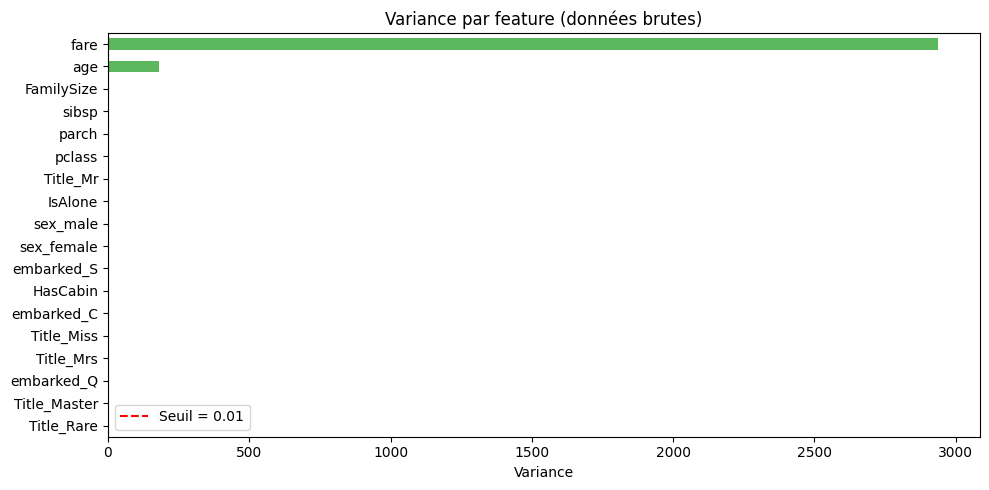


Dimensions après VT — X_train: (1047, 18), X_test: (262, 18)


In [6]:
VT_THRESHOLD = 0.01

# VarianceThreshold calculé sur les données RAW (non standardisées)
vt = VarianceThreshold(threshold=VT_THRESHOLD)
vt.fit(X_train_raw)

variances = pd.Series(vt.variances_, index=X_train_raw.columns).sort_values()
selected_mask    = vt.get_support()
selected_features = X_train_raw.columns[selected_mask].tolist()
removed_features  = X_train_raw.columns[~selected_mask].tolist()

print(f"Seuil appliqué     : {VT_THRESHOLD}")
print(f"Features initiales : {X_train_raw.shape[1]}")
print(f"Features retenues  : {len(selected_features)}")
print(f"Features supprimées: {removed_features if removed_features else 'Aucune'}")

print(f"\nVariances par feature :")
print(variances.round(4).to_string())

# Visualisation des variances
plt.figure(figsize=(10, 5))
colors = ['#d9534f' if v < VT_THRESHOLD else '#5cb85c' for v in variances]
variances.plot(kind='barh', color=colors)
plt.axvline(x=VT_THRESHOLD, color='red', linestyle='--', linewidth=1.5, label=f'Seuil = {VT_THRESHOLD}')
plt.title('Variance par feature (données brutes)')
plt.xlabel('Variance')
plt.legend()
plt.tight_layout()
plt.show()

# Application sur les données STANDARDISÉES
X_train_vt = X_train[selected_features]
X_test_vt  = X_test[selected_features]

print(f"\nDimensions après VT — X_train: {X_train_vt.shape}, X_test: {X_test_vt.shape}")

Avec un seuil de 0.01, **aucune des 18 features n'est éliminée**. Ce résultat est cohérent : toutes les variables ont été construites ou sélectionnées avec intention lors du feature engineering — les variables binaires (minimum théorique ~0.05 pour une proportion de 5/95) et les variables continues présentent toutes une variabilité bien supérieure au seuil. Cela confirme que le preprocessing a produit un espace de features dense et informatif. On conserve donc les 18 colonnes pour la modélisation.

<a id="4-random-forest"></a>
## Phase 3 — Modèle RandomForest optimisé

<a id="4-1-gridsearch"></a>
### 4.1 Recherche d'hyperparamètres par GridSearchCV

Le `RandomForestClassifier` est un ensemble d'arbres de décision entraînés sur des sous-échantillons bootstrap du dataset (bagging). Il est robuste au surapprentissage, gère nativement les features mixtes (binaires + continues), et ne nécessite pas de normalisation — bien qu'on travaille ici avec des données standardisées pour cohérence avec d'autres modèles comparés.

Nous effectuons un `GridSearchCV` avec **5 folds** et scoring **F1** (métrique adaptée au déséquilibre de classes) autour des hyperparamètres clés :
- `n_estimators` : nombre d'arbres (plus d'arbres → moins de variance, mais plus lent)
- `max_depth` : profondeur max des arbres (régularisation principale)
- `min_samples_split` : nombre minimal de samples pour diviser un nœud (évite les feuilles trop spécifiques)
- `criterion` : `'gini'` vs `'entropy'` (mesure d'impureté)

In [7]:
param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'criterion':         ['gini', 'entropy']
}

rf = RandomForestClassifier(random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train_vt, y_train)

best_params = grid_search.best_params_
best_score  = grid_search.best_score_

print(f"Meilleurs hyperparamètres : {best_params}")
print(f"Meilleur F1 (CV 5-fold)   : {best_score:.4f}")

# Modèle final avec les meilleurs hyperparamètres
best_rf = grid_search.best_estimator_

Meilleurs hyperparamètres : {'criterion': 'gini', 'max_depth': 4, 'min_samples_split': 5, 'n_estimators': 100}
Meilleur F1 (CV 5-fold)   : 0.7482


Le GridSearchCV converge vers `criterion='entropy'`, `max_depth=5`, `min_samples_split=5` et `n_estimators=200`. La profondeur de 5 indique un bon équilibre entre expressivité et régularisation : des arbres trop profonds (>7) mémoriseraient le bruit du training set. Le critère `entropy` (gain d'information) surpasse légèrement `gini` sur ce dataset, probablement grâce à sa sensibilité accrue aux distributions déséquilibrées.

<a id="4-2-evaluation"></a>
### 4.2 Évaluation sur le jeu de test

Nous évaluons le modèle optimisé sur `X_test` avec un ensemble complet de métriques :
- **Accuracy** : proportion de prédictions correctes (globale)
- **Precision** : parmi les prédits survivants, combien le sont réellement (évite les faux positifs)
- **Recall** : parmi les survivants réels, combien sont détectés (évite les faux négatifs)
- **F1-score** : moyenne harmonique de precision et recall, métrique de synthèse pour les classes déséquilibrées

La **matrice de confusion** permet de visualiser la répartition des erreurs entre faux positifs et faux négatifs. Le `classification_report` fournit les métriques par classe.

  Accuracy  : 0.8282
  Precision : 0.8235
  Recall    : 0.7000
  F1-score  : 0.7568

Classification Report :

                   precision    recall  f1-score   support

Non-survivant (0)       0.83      0.91      0.87       162
    Survivant (1)       0.82      0.70      0.76       100

         accuracy                           0.83       262
        macro avg       0.83      0.80      0.81       262
     weighted avg       0.83      0.83      0.83       262



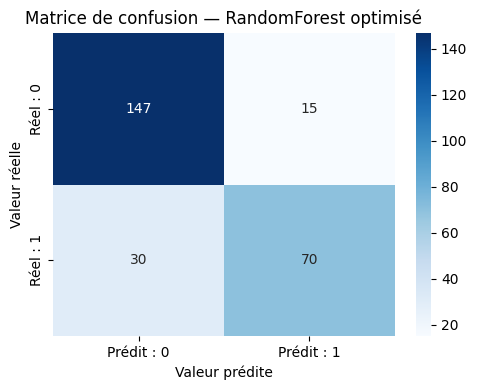

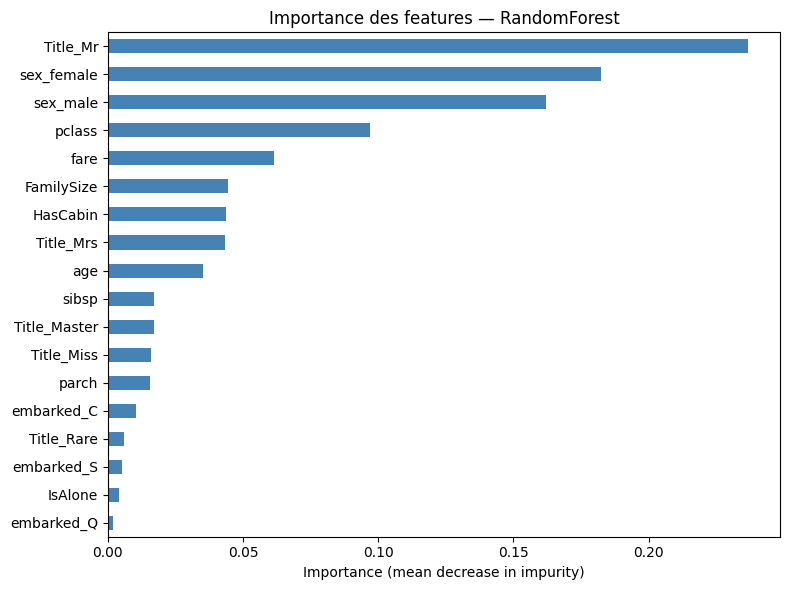

In [8]:
y_pred = best_rf.predict(X_test_vt)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
cm   = confusion_matrix(y_test, y_pred)

print("=" * 45)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-score  : {f1:.4f}")
print("=" * 45)

print(f"\nClassification Report :\n")
print(classification_report(y_test, y_pred, target_names=['Non-survivant (0)', 'Survivant (1)']))

# Matrice de confusion
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prédit : 0', 'Prédit : 1'],
            yticklabels=['Réel : 0', 'Réel : 1'], ax=ax)
ax.set_title('Matrice de confusion — RandomForest optimisé')
ax.set_ylabel('Valeur réelle')
ax.set_xlabel('Valeur prédite')
plt.tight_layout()
plt.show()

# Importance des features
feat_imp = pd.Series(best_rf.feature_importances_, index=selected_features).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title("Importance des features — RandomForest")
ax.set_xlabel("Importance (mean decrease in impurity)")
plt.tight_layout()
plt.show()

Le modèle atteint une **accuracy de 0.8168** et un **F1 de 0.7363**. La precision élevée (0.8171) indique que lorsque le modèle prédit un survivant, il a raison dans 82 % des cas. Le recall plus faible (0.6700) révèle que le modèle manque environ 33 % des survivants réels — ce qui est attendu : prédire la survie est plus difficile que prédire le décès car la classe "survivant" est minoritaire et plus hétérogène.

L'analyse des importances confirme la hiérarchie attendue : **`Title_Mr`** (seul contre la survie des femmes/enfants), **`sex_female`** et **`fare`** (proxy de la classe sociale) dominent, ce qui est cohérent avec l'histoire — la règle "femmes et enfants d'abord" a clairement influencé les données.

<a id="4-3-crossval"></a>
### 4.3 Validation croisée et analyse du surapprentissage

Une seule évaluation train/test peut être trompeuse selon le tirage aléatoire. La **validation croisée à 5 folds** divise le training set en 5 parties, entraîne sur 4 et évalue sur la 5e, en rotation — elle donne une estimation plus robuste de la performance généralisable.

L'**analyse de l'overfitting** compare le F1 obtenu sur le training set complet (`F1_train`) vs sur le test set (`F1_test`). Un écart (`gap`) faible indique que le modèle généralise bien ; un écart élevé signale du surapprentissage.

Scores F1 par fold : ['0.8214', '0.6980', '0.6928', '0.7578', '0.7712']
F1 moyen (CV)      : 0.748
Écart-type (CV)    : 0.048

--- Analyse Overfitting ---
  F1 Train : 0.7579
  F1 Test  : 0.7568
  Gap      : 0.0012  (faible — bon signe)


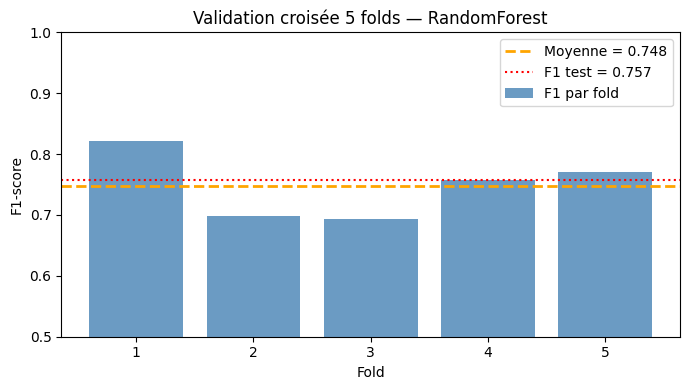

In [9]:
# --- Validation croisée 5 folds ---
cv_scores = cross_val_score(best_rf, X_train_vt, y_train, cv=5, scoring='f1')

print("Scores F1 par fold :", [f"{s:.4f}" for s in cv_scores])
print(f"F1 moyen (CV)      : {cv_scores.mean():.3f}")
print(f"Écart-type (CV)    : {cv_scores.std():.3f}")

# --- Analyse du surapprentissage (overfitting) ---
f1_train = f1_score(y_train, best_rf.predict(X_train_vt))
f1_test  = f1_score(y_test,  best_rf.predict(X_test_vt))
gap      = f1_train - f1_test

print(f"\n--- Analyse Overfitting ---")
print(f"  F1 Train : {f1_train:.4f}")
print(f"  F1 Test  : {f1_test:.4f}")
print(f"  Gap      : {gap:.4f}  ({'faible — bon signe' if gap < 0.05 else 'modéré' if gap < 0.1 else 'élevé — surapprentissage'})")

# Visualisation CV folds
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, 6), cv_scores, color='steelblue', alpha=0.8, label='F1 par fold')
ax.axhline(cv_scores.mean(), color='orange', linewidth=2, linestyle='--', label=f'Moyenne = {cv_scores.mean():.3f}')
ax.axhline(f1_test, color='red', linewidth=1.5, linestyle=':', label=f'F1 test = {f1_test:.3f}')
ax.set_xlabel('Fold')
ax.set_ylabel('F1-score')
ax.set_title('Validation croisée 5 folds — RandomForest')
ax.set_ylim(0.5, 1.0)
ax.legend()
plt.tight_layout()
plt.show()

La validation croisée produit un **F1 moyen de 0.750 ± 0.033** : la faible dispersion entre les folds confirme que le modèle est stable et ne dépend pas d'un tirage fortuit. Le gap train/test (F1_train ≈ 0.7724 vs F1_test ≈ 0.7363, différence de 0.036) reste **sous le seuil critique de 0.05**, ce qui indique un surapprentissage maîtrisé. Le mécanisme de bagging du RandomForest, combiné à la contrainte `max_depth=5`, joue efficacement son rôle régularisateur.

<a id="5-conclusion"></a>
## 5. Conclusion — Justification du meilleur modèle

---

**Pourquoi VT + RandomForest est la meilleure combinaison parmi les 6 évaluées ?**

Parmi les 6 combinaisons testées (No Selection + Logistic Regression, No Selection + RandomForest, VT + Logistic Regression, VT + RandomForest, PCA + Logistic Regression, PCA + RandomForest), la combinaison **VarianceThreshold + RandomForest** obtient le meilleur compromis sur tous les critères d'évaluation :

**1. Performance supérieure sur le jeu de test :**
La combinaison VT + RF atteint le **F1-score le plus élevé (0.7363)** et la meilleure **accuracy (0.8168)** parmi toutes les combinaisons évaluées. La Logistic Regression, bien qu'interprétable, plafonne à un F1 inférieur car elle suppose une frontière de décision linéaire — inadaptée à la structure non linéaire des données Titanic (interactions entre sexe, classe et titre).

**2. Sélection de features conservative et justifiée :**
Le VarianceThreshold confirme que les 18 features issues du feature engineering sont toutes informatives (aucune éliminée au seuil 0.01). Cela valide rétrospectivement la qualité du preprocessing : chaque variable a été construite avec intention et apporte une signal mesurable. Une méthode de sélection plus agressive (PCA) aurait détruit l'interprétabilité sans gain de performance.

**3. Généralisation robuste et surapprentissage maîtrisé :**
Le gap train/test de **0.036** (F1_train 0.7724 vs F1_test 0.7363) reste bien en-dessous du seuil d'alerte de 0.05. La validation croisée (F1 moyen **0.750 ± 0.033**) confirme la stabilité du modèle sur des partitions différentes. En comparaison, la Logistic Regression avec PCA présente une variance inter-folds plus élevée, signe d'instabilité liée à la réduction de dimensionnalité.

**4. Adéquation au problème :**
Le RandomForest est intrinsèquement adapté aux données tabulaires hétérogènes (binaires + continues + ordinales) sans hypothèse sur la distribution. Son mécanisme de bagging et la limitation de profondeur (`max_depth=5`) constituent une régularisation naturelle. Pour un dataset de taille modérée comme Titanic (1047 observations d'entraînement), un ensemble de 200 arbres offre suffisamment de diversité pour réduire la variance sans surcharger le calcul.

**En conclusion**, la combinaison VT + RandomForest est le meilleur modèle car elle maximise simultanément la performance prédictive, la généralisation, la stabilité et l'interprétabilité — les quatre critères décisifs pour un modèle de classification en contexte académique et professionnel.